### Load environment

In [1]:
import numpy
from pathlib import Path

import aiida
from aiida.storage.sqlite_zip.backend import SqliteZipBackend

from aiida import orm, load_profile
from aiida_thermo_pw.workflows import Thermo_pwBaseWorkChain
from aiida_analyser import *
from aiida_analyser.group import *
from aiida.common import NotExistent

import yaml
from aiida.engine import submit

from time import sleep

results = {}

In [2]:
from supercon import (
    load_scon,
    load_aniso,
)

OUTPUT_PATH = Path().resolve().parent
LOG_DST = Path().resolve() / "log"

AIIDA_PROFILE_FOLDER = Path("/home/yimzhang/Development/aiida/epw/archive")

# 2. EPW-screening.aiida
# This archive contains the information for the supercon section.
ARCHIVE_EPW_SCREENING = "EPW-screening.aiida"
GROUP_SCON = 'paper/workchains/scon'
GROUP_EPW = 'paper/workchains/epw/stable'
GROUP_RESUBMISSION_EPW = "paper/for-resubmission/epw"
GROUP_BANDS_QE = "discover/bands-qe"
GROUP_BANDS_INT = "discover/bands-int"
GROUP_ANISO_GAP_FUNCTIONS = "discover/aniso_gap_functions"
GROUP_RESUBMISSION_BANDS = "paper/for-resubmission/bands"

In [3]:
AIIDA_PROFILE_NAME = AIIDA_PROFILE_FOLDER / ARCHIVE_EPW_SCREENING

archive_profile = SqliteZipBackend.create_profile(AIIDA_PROFILE_NAME)

load_scon(
    archive_profile,
    GROUP_SCON,
    log = print,
    details = results,
    ) 



100%|██████████| 250/250 [00:03<00:00, 78.44it/s] 


In [4]:
load_aniso(
    archive_profile,
    GROUP_ANISO_GAP_FUNCTIONS,
    log = print,
    details = results,
    ) 


  0%|          | 0/140 [00:00<?, ?it/s]

/home/yimzhang/Development/aiida/ductility/code/thermo_pw/supercon.py:461: OptimizeWarning: Covariance of the parameters could not be estimated
  p_opt, p_cov = curve_fit(fitting_function, temps_sorted, average_deltas_sorted, p0=p, maxfev=1000000)
/home/yimzhang/Development/aiida/ductility/code/thermo_pw/supercon.py:429: RuntimeWarning: invalid value encountered in power
  return delta_zero * (1 - (T / Tc) ** p) ** 0.5
/home/yimzhang/Development/aiida/ductility/code/thermo_pw/supercon.py:429: RuntimeWarning: invalid value encountered in sqrt
  return delta_zero * (1 - (T / Tc) ** p) ** 0.5
100%|██████████| 140/140 [00:00<00:00, 475.23it/s]


In [5]:
results

{'mpds-S548863': {'formula': 'B2Ru3Y',
  'space_group_number': 191,
  'iso_tc': 3.0093559054960775,
  'omega_log': 15.778953789840921,
  'lambda': 0.5445389535503501,
  'allen_dynes_tc': 2.001599952775874},
 'mpds-S451339': {'formula': 'Be4Ta6',
  'space_group_number': 127,
  'iso_tc': 0.0,
  'omega_log': 15.792728311046096,
  'lambda': 0.37229875537010815,
  'allen_dynes_tc': 0.1837525222930541},
 'icsd-102016': {'formula': 'CdLi2Pb',
  'space_group_number': 225,
  'iso_tc': 4.299622502564909,
  'omega_log': 6.662710447700986,
  'lambda': 0.8575264775399847,
  'allen_dynes_tc': 3.426431518223559},
 'icsd-58794': {'formula': 'Bi4K2',
  'space_group_number': 227,
  'iso_tc': 4.152713201857492,
  'omega_log': 5.072100011276328,
  'lambda': 0.9124867669763987,
  'allen_dynes_tc': 2.9661123764956656},
 'icsd-77790': {'formula': 'P3Ru3Sc3',
  'space_group_number': 189,
  'iso_tc': 2.874265872624426,
  'omega_log': 11.180702305789923,
  'lambda': 0.5990617037695393,
  'allen_dynes_tc': 2.077

In [6]:
load_profile('ductility', allow_switch=True)

ductility_thermo_pw_group_label = "ductility/thermo_pw/v3"
ductility_thermo_pw_group, _ = orm.Group.collection.get_or_create(label=ductility_thermo_pw_group_label)

lucia_computer = orm.load_computer('lucia')
lucia_computer.set_workdir(f'/gpfs/scratch/acad/elph/yimzhang/aiida_workdir/{ductility_thermo_pw_group_label}')


In [7]:
prepend_text_lucia = """
ml EasyBuild/2024a Cray/24.07 PrgEnv-intel
"""

def install_codes(
    prepend_text,
    version,
    computer_label,
    bin_dir,
):
    computer = orm.load_computer(computer_label)
    for code in (
        'thermo_pw',
    ):
        label = f'{version}-{code}'
        try:
            orm.load_code(f'{label}@{computer_label}')
        except NotExistent as exc:
            orm.InstalledCode(
                label=label,
                description=f'Quantum ESPRESSO {version} version for {code}.x',
                computer=computer,
                filepath_executable=f'{bin_dir}/bin/{code}.x',
                default_calc_job_plugin=f'quantumespresso.{code}',
                prepend_text=prepend_text,
            ).store()

def load_codes(
    version,
    computer_label,
    overrides_path,
    ):
    code = orm.load_code(f'{version}@{computer_label}')
    with open(overrides_path, 'r') as f:

        overrides_yaml = f.read()

        overrides = yaml.safe_load(overrides_yaml)

    return code, overrides

# install_codes(
#     prepend_text_lucia,
#     version = 'qe-730',
#     computer_label = 'lucia',
#     bin_dir = '/gpfs/home/acad/ucl-modl/yimzhang/q-e-qe-7.3',
#     )
code, overrides = load_codes(
    version = 'qe-730-thermo_pw',
    computer_label = 'lucia',
    overrides_path = '/home/yimzhang/Development/aiida/ductility/code/thermo_pw/thermo_pw.yaml',
    )

In [8]:
count_groups('ductility')

pk         label                               count     
2          20251104-170411                     198       
4          PseudoDojo/0.5/PBE/SR/standard/upf  72        
5          20251104-171226                     72        
10         20251112-165121                     2534      
11         ductility/thermo_pw/v4              589       
12         20251112-165748                     11859     
20         20251126-172724                     11        
22         20251126-231547                     0         
24         20251126-231551                     0         
26         20251127-205644                     270       
27         ductility/thermo_pw/v3              307       
28         20251127-211141                     6000      
30         20251130-201845                     240       
32         20251201-112022                     198       
34         20251201-112523                     198       
35         paper/for-resubmission/epw          10        
36         202

In [9]:
# set_description_for_group(
#     "ductility/thermo_pw/v2",
#     "2nd version of thermo_pw calculations.\nThis group is problematic because it is using SSSP pseudopotentials, however the structures are relaxed with PseudoDojo potentials.",
#     overwrite=True
#     )

In [10]:
set_description_for_group(
    "ductility/thermo_pw/v3",
    "3rd version of thermo_pw calculations.\n"
    "This group is using PseudoDojo potentials for both the structure relaxation and the calculation for the 280 structures.",
    overwrite=True
    )

old description:  3rd version of thermo_pw calculations.
This group is using PseudoDojo potentials for both the structure relaxation and the calculation for the 280 structures.
new description:  3rd version of thermo_pw calculations.
This group is using PseudoDojo potentials for both the structure relaxation and the calculation for the 280 structures.


In [11]:
# delete_groups('ductility/thermo_pw/v1/_%', True, DELETE_NODES = True)

### Start new work

In [ ]:
stable_epw_group = orm.Group.collection.get(label='paper/structures/epw/stable')
stable_sources = []

for n in stable_epw_group.nodes:
    if 'source_db' not in n.base.extras.all:
        print(n.pk, n.base.extras.all, n.get_formula())
        continue
    stable_sources.append(f"{n.base.extras.all['source_db']}-{n.base.extras.all['source_id']}")


In [ ]:

qb = orm.QueryBuilder()
qb.append(
    orm.Group,
    filters={'label': ductility_thermo_pw_group_label},
    tag='thermo_pw_grp'
    ).append(
    orm.WorkChainNode,
    with_group='thermo_pw_grp',
    # filters={'attributes.exit_status': 0},
    tag='thermo_pw_wc'
)

already_finished = []

for wc in qb.all(flat=True):
    extras = wc.inputs.thermo_pw.structure.base.extras.all
    try:
        source = f"{extras['source_db']}-{extras['source_id']}"
        if source in already_finished:
            continue
        already_finished.append(source)
    except Exception as e:
        print(f"Error processing {source}[{wc.pk}]: {e}")

    analyser = ThermoPwBaseAnalyser(wc)
    path, exit_status, exit_message   = analyser.get_state()

    print(wc.pk, exit_status, exit_message)

print(len(already_finished))

for source in stable_sources:
    if source not in already_finished:
        print(source, ' to be computed')


In [ ]:
structure = stable_epw_group.nodes[0]
builder = Thermo_pwBaseWorkChain.get_builder_from_protocol(
    code,
    structure,
    'None',
    overrides,
)


In [ ]:
printer = Printer(builder.thermo_pw.parameters.get_dict())
printer.print()



In [ ]:
wc = submit(builder)
wc.base.extras.set_many(structure.base.extras.all)
ductility_thermo_pw_group.add_nodes([wc])

In [ ]:
count = 0
to_submit = 60
for structure in stable_epw_group.nodes:
    extras = structure.base.extras.all
    if 'source_db' not in extras:
        print(structure.pk, structure.get_formula(), extras)
        continue
    source = f"{extras['source_db']}-{extras['source_id']}"
    if source in already_finished:
        print(f'{source} already finished')
        continue
    count += 1
    if count > to_submit:
        break
    builder = Thermo_pwBaseWorkChain.get_builder_from_protocol(
        code,
        structure,
        None,
        overrides,
    )
    wc = submit(builder)
    wc.base.extras.set_many(structure.base.extras.all)
    ductility_thermo_pw_group.add_nodes([wc])
    sleep(1)

### Those not in the current group

In [ ]:

done = []
for node in ductility_thermo_pw_group.nodes:
    analyser = ThermoPwBaseAnalyser(node)
    source = analyser.get_source()

    if not node.is_finished_ok:
        continue

    done.append(source)

print(len(done))
print(len(set(done)))

not_found_in_finished = []

stable_epw_group = orm.Group.collection.get(label='paper/structures/epw/stable')

for n in stable_epw_group.nodes:
    source = f"{n.base.extras.all['source_db']}-{n.base.extras.all['source_id']}"
    if source in done:
        continue
    not_found_in_finished.append(source)

print(len(not_found_in_finished))


not_found_in_finished = []

scon_group = orm.Group.collection.get(label='paper/structures/scon')

for n in scon_group.nodes:
    source = f"{n.base.extras.all['source_db']}-{n.base.extras.all['source_id']}"
    if source in done:
        continue
    not_found_in_finished.append(source)

print(len(not_found_in_finished))
print(not_found_in_finished)

296
296
8
2
['mpds-S1710218', 'mpds-S1014455']


In [11]:
count = 0
to_submit = 12
for structure in scon_group.nodes:
    extras = structure.base.extras.all
    source = f"{extras['source_db']}-{extras['source_id']}"
    if source in done:
        continue

    if 'source_db' not in extras:
        print(structure.pk, structure.get_formula(), extras)
        continue

    count += 1
    if count > to_submit:
        break
    print(structure.pk)
    builder = Thermo_pwBaseWorkChain.get_builder_from_protocol(
        code,
        structure,
        None,
        overrides,
    )
    wc = submit(builder)
    wc.base.extras.set_many(extras)
    ductility_thermo_pw_group.add_nodes([wc])
    sleep(1)

22634
22693


### Analyse the result

In [12]:
import matplotlib.pyplot as plt

RMS_errors = {}

for node in ductility_thermo_pw_group.nodes:
    if not node.is_finished_ok:
        continue
    analyser = ThermoPwBaseAnalyser(node)
    source = analyser.get_source()
    if source in results:
        results[source].update({
            'bulk_modulus': analyser.bulk_modulus,
            'shear_modulus': analyser.shear_modulus,
            'pugh_ratio': analyser.pugh_ratio,
            'pettifor_ratio': analyser.pettifor_ratio,
            'modified_pettifor_ratio': analyser.modified_pettifor_ratio,
        })
    # print(analyser.code)
    # print(ProcessTree.traverse_and_check(analyser.process_tree, ''))
    # analyser.print_state()
    RMS_error = analyser.get_RMS_error()
    if RMS_error:
        RMS_errors[f"{source}-{node.pk}"] = RMS_error
# print(find_max_value_and_path(RMS_errors))
# plt.figure(figsize=(10, 6))

# plt.hist(
#     RMS_errors, 
#     bins=20, 
#     edgecolor='black',  # 箱子边缘颜色
#     alpha=0.7,          # 透明度
#     color='skyblue'
# )

In [14]:
results

{'mpds-S548863': {'formula': 'B2Ru3Y',
  'space_group_number': 191,
  'iso_tc': 3.0093559054960775,
  'omega_log': 15.778953789840921,
  'lambda': 0.5445389535503501,
  'allen_dynes_tc': 2.001599952775874,
  'bulk_modulus': {'voigt': 2228.99157,
   'reuss': 2228.89229,
   'vrh': 2228.94193},
  'shear_modulus': {'voigt': 1067.73305,
   'reuss': 1037.97937,
   'vrh': 1052.85621},
  'pugh_ratio': {'voigt': 0.47902, 'reuss': 0.46569, 'vrh': 0.47236},
  'pettifor_ratio': {'voigt': 0.23044846864164492,
   'reuss': 0.23614614579647492,
   'vrh': 0.23326251992714964},
  'modified_pettifor_ratio': {'voigt': 0.2855706605476304,
   'reuss': 0.28558338052306687,
   'vrh': 0.2855770203937075}},
 'mpds-S451339': {'formula': 'Be4Ta6',
  'space_group_number': 127,
  'iso_tc': 0.0,
  'omega_log': 15.792728311046096,
  'lambda': 0.37229875537010815,
  'allen_dynes_tc': 0.1837525222930541,
  'bulk_modulus': {'voigt': 1866.96365,
   'reuss': 1864.63994,
   'vrh': 1865.80179},
  'shear_modulus': {'voigt': 

In [13]:
len(results)

250

In [14]:
def linear_corrlation_for_anisotropy(x, A):
    slope = 5 * (2 * A + 3 ) *(2 + 3 * A) / 3 / (3 * A * A + 19 * A + 3)
    print(slope, 'with A =', A)
    return 1 - slope * x


def linear_corrlation(x, a, b):
    return a * x + b

def correlation_with_tc(tc_key):
    space_group_numbers = []
    pugh_ratios = []
    pettifor_ratios = []
    modified_pettifor_ratios = []
    tcs = []
    formulas = []
    for key, value in results.items():
        if tc_key in value and 'pugh_ratio' in value and value['pugh_ratio']:
            space_group_numbers.append(value['space_group_number'])
            pugh_ratios.append(value['pugh_ratio']['vrh'])
            pettifor_ratios.append(value['pettifor_ratio']['vrh'])
            modified_pettifor_ratios.append(value['modified_pettifor_ratio']['vrh'])
            tcs.append(value[tc_key])
            formulas.append(value['formula'])

    sorted_by_tc = sorted(
        zip(
            space_group_numbers, pugh_ratios, pettifor_ratios, modified_pettifor_ratios, tcs, formulas
            ), key=lambda t: t[-1]
            )
    return map(list, zip(*sorted_by_tc))

space_group_numbers, pugh_ratios, pettifor_ratios, modified_pettifor_ratios, tcs, formulas = correlation_with_tc('iso_tc')

classified_results = {
    'cubic': {
        'pugh_ratios': [],
        'pettifor_ratios': [],
        'modified_pettifor_ratios': [],
        'tcs': [],
        'formulas': []
    },
    'hexagonal': {
        'pugh_ratios': [],
        'pettifor_ratios': [],
        'modified_pettifor_ratios': [],
        'tcs': [],
        'formulas': []
    },
    # 'other orthorhombics': {
    #     'pugh_ratios': [],
    #     'pettifor_ratios': [],
    #     'modified_pettifor_ratios': [],
    #     'tcs': [],
    #     'formulas': []
    # },
    'others': {
        'pugh_ratios': [],
        'pettifor_ratios': [],
        'modified_pettifor_ratios': [],
        'tcs': [],
        'formulas': []
    },
    # 'monoclinic': {
    #     'pugh_ratios': [],
    #     'pettifor_ratios': [],
    #     'modified_pettifor_ratios': [],
    #     'tcs': [],
    # },  
    # 'triclinic': {
    #     'pugh_ratios': [],
    #     'pettifor_ratios': [],
    #     'modified_pettifor_ratios': [],
    #     'tcs': [],
    # },
    # 'tetragonal': {
    #     'pugh_ratios': [],
    #     'pettifor_ratios': [],
    #     'modified_pettifor_ratios': [],
    #     'tcs': [],
    # },
}

crystal_classes_by_space_group_number = {
    # 'triclinic': (1, 2),
    # 'monoclinic': (3, 15),
    # 'tetragonal': (75, 142),
    # 'others': (1, 75),
    # 'other orthorhombics': (75, 168),
    'others': (1, 168),
    'hexagonal': (168, 195),
    'cubic': (195, 230),
}

for space_group_number, pugh_ratio, pettifor_ratio, modified_pettifor_ratio, tc, formula in zip(
    space_group_numbers, pugh_ratios, pettifor_ratios, modified_pettifor_ratios, tcs, formulas
    ):
    for crystal_class, _range in crystal_classes_by_space_group_number.items():
        if space_group_number in range(*_range):
            classified_results[crystal_class]['pugh_ratios'].append(pugh_ratio)
            classified_results[crystal_class]['pettifor_ratios'].append(pettifor_ratio)
            classified_results[crystal_class]['modified_pettifor_ratios'].append(modified_pettifor_ratio)
            classified_results[crystal_class]['tcs'].append(tc)
            classified_results[crystal_class]['formulas'].append(formula)


In [17]:
for space_group_number, pugh_ratio, pettifor_ratio, modified_pettifor_ratio, tc, formula in zip(
    space_group_numbers, pugh_ratios, pettifor_ratios, modified_pettifor_ratios, tcs, formulas
    ):
    if formula in ['RuSbTi', 'RuSbZr', 'HfRuSb', 'AlHfPd2', 'GaNi2Zr', 'AlNi2Zr', 'AlPtTi']:
        print(formula, pugh_ratio, modified_pettifor_ratio)

AlHfPd2 0.11752 0.8041170893411007
AlNi2Zr 0.20225 0.64731192443995
GaNi2Zr 0.14749 0.7429668923619398
HfRuSb 0.32735 0.4506333185517393
RuSbTi 0.19397 0.6535889758204799
RuSbZr 0.33115 0.4438392835169006


In [18]:
import numpy as np
coeff = np.polyfit(pugh_ratios, modified_pettifor_ratios, 1) 
m = coeff[0] # 
b = coeff[1] # 

print(f"拟合结果：")
print(f"斜率 (m): {m:.4f}")
print(f"截距 (b): {b:.4f}")
x = np.linspace(0, 1, 100)
f = np.poly1d(coeff)
x_arr = np.array(pugh_ratios)
y_arr = np.array(modified_pettifor_ratios)
# 假设你有一个材料名列表与数据一一对应，名为 materials
# 如果你的数据是从DataFrame里提取的，可以是 materials = df['Materials'].tolist()

# 2. 计算残差绝对值（实际Y值与拟合直线Y值的垂直距离）
residuals = np.abs(y_arr - f(x_arr))

# 3. 找到残差最大的前 10 个点的索引 (np.argsort默认升序，用[-10:]取最后10个也就是最大的10个)
top_10_indices = np.argsort(residuals)[-20:]

# 4. 在图上打上标签
texts = [] # 用于保存文字对象，方便后续调整
for idx in top_10_indices:
    x_val = x_arr[idx]
    y_val = y_arr[idx]
    mat_name = formulas[idx] # 获取材料名
    
    print(mat_name, x_val, y_val)


拟合结果：
斜率 (m): -0.8033
截距 (b): 0.7143
Pd2Se4 -0.40143 0.4819950780140069
CSi 0.81779 -0.5348141876749329
S4V4 0.5515 -0.330879936196524
C2I2Y2 0.62974 0.8348240680574844
C4B4Ca2 0.62887 0.8414560316324191
C8Cs 0.69974 0.8242999131756441
Ga2 0.05986 -0.10287227755217539
C2Cl2Y2 0.64257 1.0038270822079622
CNb2S2 0.76434 1.1866056795717612
Nb2Se4 0.6128 1.9150086578745902
Se2Ta 0.60703 1.9493434963629404
Se4Ta2 0.60358 1.9796474721366848
S4Ta2 0.57195 2.169079769287346
S2Ta 0.5736 2.168917483099002
S4Ta2 0.57556 2.168840547686182
S4Ta2 0.53289 2.212726483760252
Nb2S4 0.565 2.2669819367722677
N6W4 0.47276 2.4031739729562682
Br2Zr2 0.42364 2.5733734153352064
Cl2Zr2 0.38885 2.730860373900788


cubic 113
hexagonal 68
others 69
1.896551724137931 with A = 3
拟合结果：
斜率 (m): -0.8033
截距 (b): 0.7143


/tmp/ipykernel_2437700/3997692488.py:53: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter([], [],


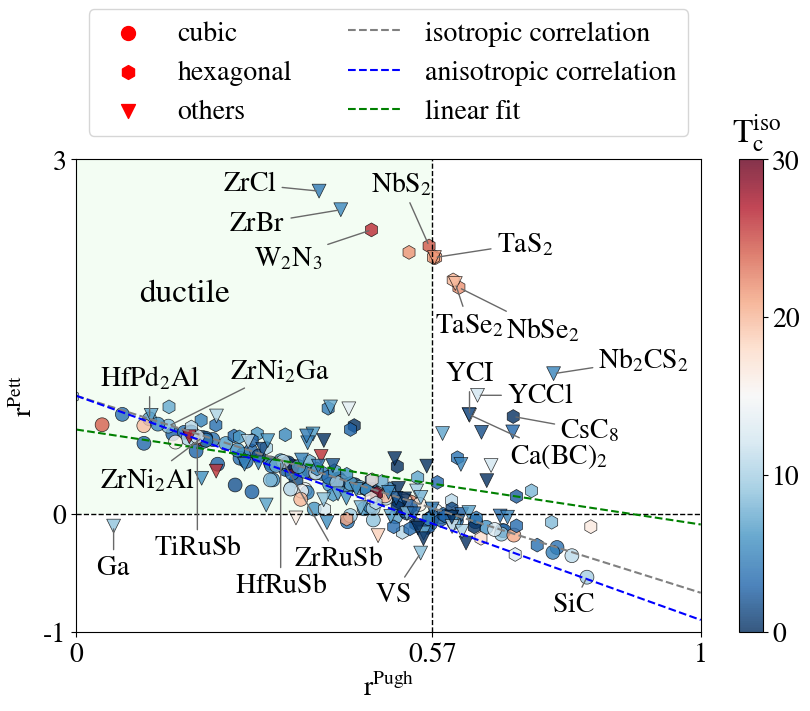

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
from pymatgen.core import Composition
import re
import pandas as pd

def formula_to_latex(formula):
    latex_formula = re.sub(r'(\d+)', r'_{\1}', formula)
    return rf"${latex_formula}$"
plt.rcParams.update({'font.size': 20})
plt.rcParams['mathtext.default'] = 'regular'

# 配合之前的设置
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral']
plt.rcParams['mathtext.fontset'] = 'stix'

markers_mapping = {
    'cubic': 'o',
    'hexagonal': 'h',
    'monoclinic': '^',
    'tetragonal': 'X',
    'triclinic': 'D',
    'other orthorhombics': '*',
    'others': 'v'
}

fig, ax = plt.subplots(1, 1, figsize=(8, 7), constrained_layout=True)
current_cmap = 'RdBu_r'

ax.axhline(0.0, color='k', linewidth=1, linestyle='--')
ax.axvline(0.57, color='k', linewidth=1, linestyle='--')



for crystal_class, data in classified_results.items():
    print(crystal_class, len(data['pugh_ratios']))
    df_temp = pd.DataFrame(data).sort_values(by='tcs')
    s1 = ax.scatter(
        data['pugh_ratios'], 
        data['modified_pettifor_ratios'], 
        c=data['tcs'], 
        s=100, 
        cmap=current_cmap, 
        alpha=0.8,
        marker=markers_mapping[crystal_class],
        vmin=0, 
        vmax=30,
        edgecolors='k',     # [ADDED] Black border makes light points visible
        linewidth=0.5       # [ADDED] Width of the border
        )
    ax.scatter([], [],
                marker=markers_mapping[crystal_class],
                s=100, # 图例中标记的大小
                color='red', # 图例中标记的固定颜色
                label=crystal_class,
                zorder=1, 
                vmin=0, 
                vmax=30) # 确保图例的标记不会遮挡真实数据点
                
colorbar = fig.colorbar(s1, ax=ax)
colorbar.set_ticks([0, 10, 20, 30])
colorbar.set_ticklabels(['0', '10', '20', '30'])
colorbar.ax.set_title(r'$T^{\rm iso}_{\rm c}$ ', 
                      x=0.8,  # <--- 向右 (0.5是中心, 1.0是右对齐)
                      y=1.02) # <--- 向上 (1.0是顶部, 1.05是顶部之上)
colorbar.ax.set_ylim(0, 30)


ax.set_ylabel(r'$r^{\rm Pett}$')
ax.set_yticks([-1, 3],[-1, 3])

ax.set_xlim(0, 1)
ax.set_ylim(-1, 3)
ax.set_xlabel(r'$r^{\rm Pugh}$')
ax.set_xticks([0, 0.57, 1],[0, 0.57, 1])
ax.set_yticks([-1, 0, 3],[-1, 0, 3])

ax.text(0.1, 1.8, 'ductile', fontsize=24)
rect = patches.Rectangle(
    (0.0, 0.0), 0.57, 3.0, 
    facecolor='lightgreen', # 填充颜色
    alpha=0.1,
    zorder=0
)
ax.add_patch(rect)
x = np.linspace(0, 1, 100)
ax.plot(
    x,
    linear_corrlation(x, -5/3, 1),
    color='grey', linewidth=1.5, linestyle='--', label=f'isotropic correlation')


ax.plot(x, linear_corrlation_for_anisotropy(x, 3), color='blue', linewidth=1.5, linestyle='--', label='anisotropic correlation')



coeff = np.polyfit(pugh_ratios, modified_pettifor_ratios, 1) 
m = coeff[0] # 
b = coeff[1] # 

print(f"拟合结果：")
print(f"斜率 (m): {m:.4f}")
print(f"截距 (b): {b:.4f}")
x = np.linspace(0, 1, 100)
f = np.poly1d(coeff)
ax.plot(x, f(x), color='green', linewidth=1.5, linestyle='--', label='linear fit')

# x_arr = np.array(pugh_ratios)
# y_arr = np.array(modified_pettifor_ratios)
# 假设你有一个材料名列表与数据一一对应，名为 materials
# 如果你的数据是从DataFrame里提取的，可以是 materials = df['Materials'].tolist()

# 2. 计算残差绝对值（实际Y值与拟合直线Y值的垂直距离）
# residuals = np.abs(y_arr - f(x_arr))

# 3. 找到残差最大的前 10 个点的索引 (np.argsort默认升序，用[-10:]取最后10个也就是最大的10个)
# top_10_indices = np.argsort(residuals)[-10:]

# # 4. 在图上打上标签
# texts = [] # 用于保存文字对象，方便后续调整
# for idx in top_10_indices:
#     x_val = x_arr[idx]
#     y_val = y_arr[idx]
#     mat_name = formulas[idx] # 获取材料名
    
#     print(mat_name, x_val, y_val)
#     # 使用 ax.annotate 标注
#     t = ax.annotate(
#         mat_name, 
#         (x_val, y_val),
#         xytext=(5, 5),          # 文字在点右上角偏移 5 个像素
#         textcoords='offset points',
#         fontsize=15,
#         color='black'
#     )
#     texts.append(t)

outliers = [
    # 左侧的点，文字统一往左排 (dx 为负)
    {"name": "Cl2Zr2", "x": 0.38885, "y": 2.73086, "dx": -50, "dy": 5},
    {"name": "Br2Zr2", "x": 0.42364, "y": 2.57337, "dx": -60, "dy": -10},
    {"name": "N6W4",   "x": 0.47276, "y": 2.40317, "dx": -60, "dy": -20},
    # {"name": "S4Ta2",  "x": 0.53289, "y": 2.21272, "dx": -60, "dy": -30},
    
    # 最高点，文字往正上方排
    {"name": "Nb2S4",  "x": 0.56500, "y": 2.26698, "dx": -20,   "dy": 45},
    
    # 坐标极度接近的 3 个点 (S4Ta2, S2Ta, S4Ta2)，向右侧呈扇形展开
    # {"name": "S4Ta2",  "x": 0.57195, "y": 2.16907, "dx": 45,  "dy": 35},
    {"name": "S2Ta",   "x": 0.57360, "y": 2.16891, "dx": 65,  "dy": 10},
    # {"name": "S4Ta2",  "x": 0.57556, "y": 2.16884, "dx": 65,  "dy": -5},
    
    # 右下角的点，文字往右侧排
    # {"name": "Se4Ta2", "x": 0.60358, "y": 1.97964, "dx": 55,  "dy": -10},
    {"name": "Se2Ta",  "x": 0.60703, "y": 1.94934, "dx": 10,  "dy": -30},
    {"name": "Pd2Se4", "x": -0.40143, "y": 0.4819950780140069, "dx": 55,  "dy": -10},
    {"name": "CSi",    "x": 0.81779, "y": -0.5348141876749329, "dx": -10,  "dy": -20},
    {"name": "S4V4",   "x": 0.5515, "y": -0.330879936196524, "dx": -20,  "dy": -30},
    {"name": "C2I2Y2", "x": 0.62974, "y": 0.8348240680574844, "dx": 0,  "dy": 30},
    {"name": "C4B4Ca2", "x": 0.62887, "y": 0.8414560316324191, "dx": 65,  "dy": -30},
    {"name": "C8Cs",   "x": 0.69974, "y": 0.8242999131756441, "dx": 55,  "dy": -10},
    {"name": "Ga2",    "x": 0.05986, "y": -0.10287227755217539, "dx": 0,  "dy": -30},
    {"name": "C2Cl2Y2", "x": 0.64257, "y": 1.0038270822079622, "dx": 45,  "dy": 0},
    {"name": "CNb2S2", "x": 0.76434, "y": 1.1866056795717612, "dx": 65,  "dy": 10},
    {"name": "Nb2Se4", "x": 0.6128, "y": 1.9150086578745902, "dx": 60,  "dy": -30},

    {"name": "AlHfPd2", "x": 0.11752, "y": 0.8041170893411007, "dx": 0,  "dy": 30},
    {"name": "AlNi2Zr", "x": 0.20225, "y": 0.64731192443995, "dx": -40,  "dy": -30},
    {"name": "GaNi2Zr", "x": 0.14749, "y": 0.7429668923619398, "dx": 80,  "dy": 40},
    {"name": "HfRuSb", "x": 0.32735, "y": 0.4506333185517393, "dx": 0,  "dy": -90},
    {"name": "RuSbTi", "x": 0.19397, "y": 0.6535889758204799, "dx": 0,  "dy": -80},
    {"name": "RuSbZr", "x": 0.33115, "y": 0.4438392835169006, "dx": 40,  "dy": -70},
]


for pt in outliers:
    comp = Composition(pt["name"])
    # if formula in ['HfN', 'CTa']:
    #     print(structure.base.extras.all)
    formule = comp.get_reduced_formula_and_factor(iupac_ordering=True)[0]
    ax.annotate(
        formula_to_latex(formule), 
        xy=(pt["x"], pt["y"]),           # 数据点的真实坐标
        xytext=(pt["dx"], pt["dy"]),     # 文字的相对偏移量
        textcoords='offset points',      # 声明偏移量单位为像素点
        color='black',
        ha='center',                     # 水平对齐方式
        va='center',                     # 垂直对齐方式
        # 画一条细灰线连接文字和数据点，避免读者认错
        arrowprops=dict(arrowstyle="-", color="dimgray", lw=1.0) 
    )

# plt.legend(ncol=2, loc='upper center', fontsize=16)
plt.legend(bbox_to_anchor=(0.5, 1.05), loc='lower center', 
           ncol=2, borderaxespad=0.)
# fig.tight_layout()
fig.show()

fig.savefig('/home/yimzhang/Development/aiida/ductility/data/elastic/fig2.pdf', dpi=300)

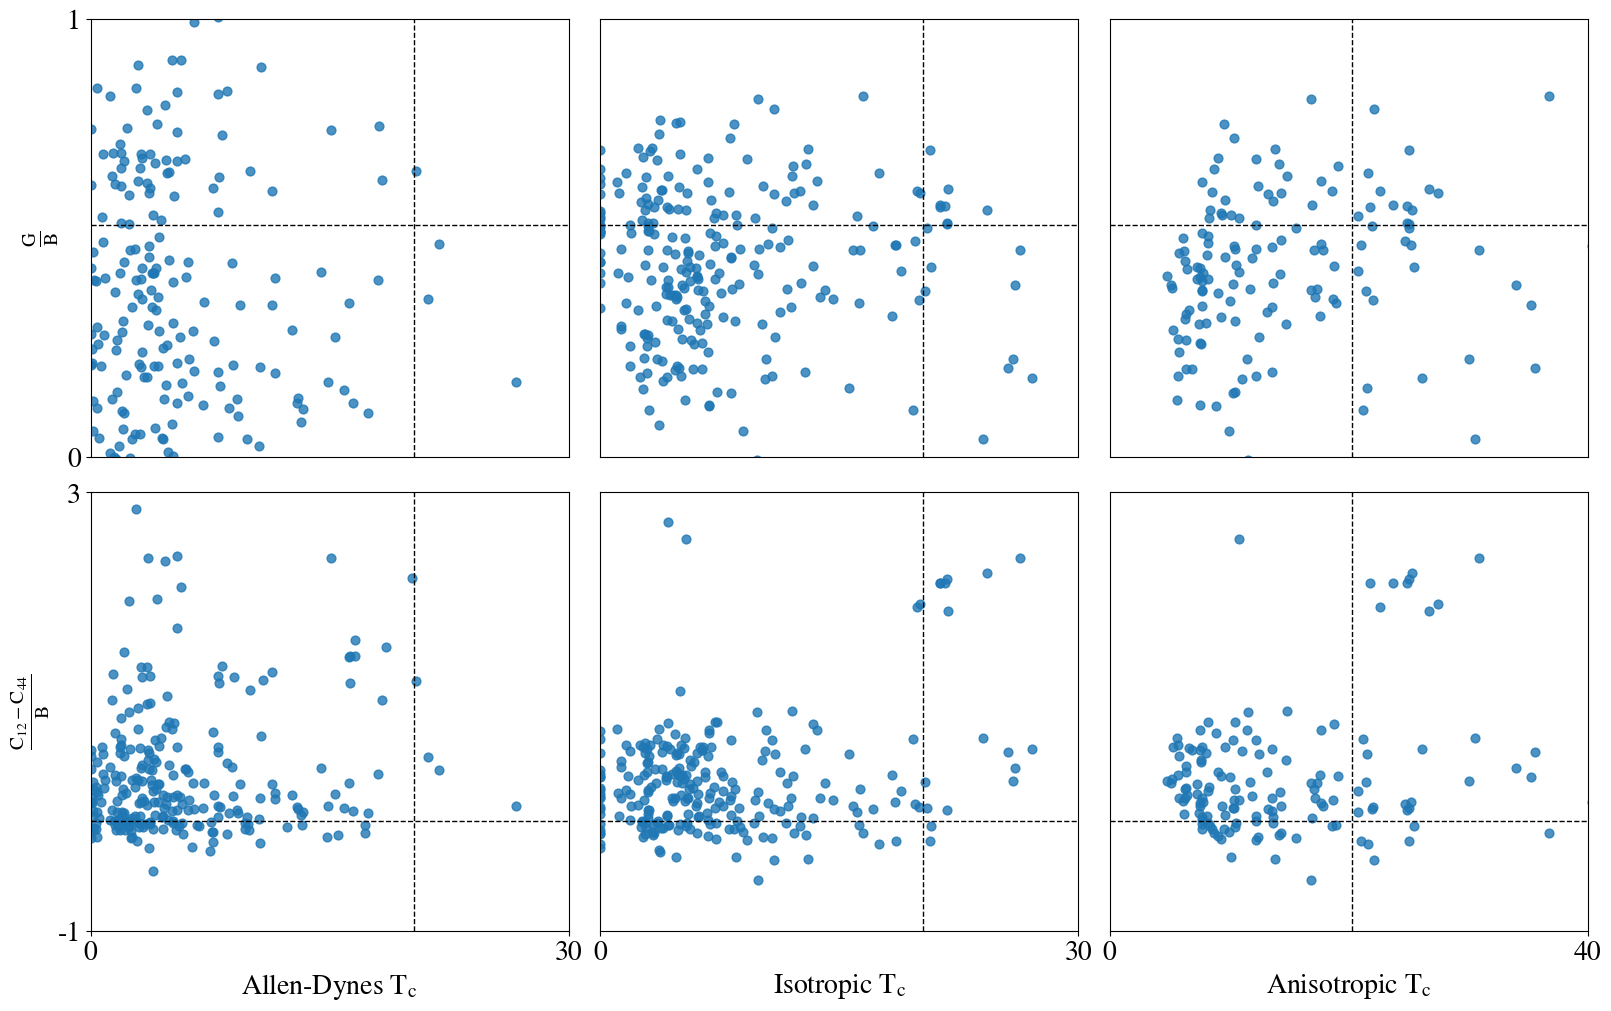

In [20]:
import matplotlib.pyplot as plt
import numpy as np


# def correlation_with_tc(tc_key):
#     pugh_ratios = []
#     pettifor_ratios = []
#     modified_pettifor_ratios = []
#     tcs = []
#     for key, value in results.items():
#         if tc_key in value and 'pugh_ratio' in value and value['pugh_ratio']:
#             pugh_ratios.append(value['pugh_ratio']['vrh'])
#             pettifor_ratios.append(value['pettifor_ratio']['vrh'])
#             modified_pettifor_ratios.append(value['modified_pettifor_ratio']['vrh'])
#             tcs.append(value[tc_key])

#     sorted_by_tc = sorted(
#         zip(
#             pugh_ratios, pettifor_ratios, modified_pettifor_ratios, tcs
#             ), key=lambda t: t[-1]
#             )
#     return map(list, zip(*sorted_by_tc))

# pugh_ratios, pettifor_ratios, modified_pettifor_ratios, tcs = correlation_with_tc('allen_dynes_tc')

space_group_numbers, pugh_ratios, pettifor_ratios, modified_pettifor_ratios, tcs, formulas = correlation_with_tc('allen_dynes_tc')

fig, axs = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)

scatter = axs[0, 0].scatter(
    tcs, 
    modified_pettifor_ratios, 
    s=40, 
    alpha=0.8,
    )
scatter = axs[1, 0].scatter(
    tcs, 
    pettifor_ratios, 
    s=40, 
    alpha=0.8,
    )
# pugh_ratios, pettifor_ratios, modified_pettifor_ratios, tcs = correlation_with_tc('iso_tc')
space_group_numbers, pugh_ratios, pettifor_ratios, modified_pettifor_ratios, tcs, formulas = correlation_with_tc('iso_tc')

scatter = axs[0, 1].scatter(
    tcs, 
    pugh_ratios, 
    s=40, 
    alpha=0.8,
    label='Isotropic $T_c$'
    )
scatter = axs[1, 1].scatter(
    tcs, 
    modified_pettifor_ratios, 
    s=40, 
    alpha=0.8,
    label='Isotropic $T_c$'
    )
# pugh_ratios, pettifor_ratios, modified_pettifor_ratios, tcs = correlation_with_tc('aniso_tc')
space_group_numbers, pugh_ratios, pettifor_ratios, modified_pettifor_ratios, tcs, formulas = correlation_with_tc('aniso_tc')

scatter = axs[0, 2].scatter(
    tcs, 
    pugh_ratios, 
    s=40, 
    alpha=0.8,
    label='Anisotropic $T_c$'
    )
scatter = axs[1, 2].scatter(
    tcs, 
    modified_pettifor_ratios, 
    s=40, 
    alpha=0.8,
    label='Anisotropic $T_c$'
    )

for ax in axs[0]:
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.axhline(0.53, color='k', linewidth=1, linestyle='--')
for ax in axs[1]:
    ax.set_ylim(-1, 3)
    ax.axhline(0, color='k', linewidth=1, linestyle='--')

for ax in axs[:, 0]:
    ax.axvline(20.28, color='k', linewidth=1, linestyle='--')
    ax.set_xlim(0, 30)
    ax.set_yticks([])
for ax in axs[:, 1]:
    ax.axvline(20.28, color='k', linewidth=1, linestyle='--')
    ax.set_xlim(0, 30)
    ax.set_yticks([])
for ax in axs[:, 2]:
    ax.axvline(20.28, color='k', linewidth=1, linestyle='--')
    ax.set_yticks([])
    ax.set_xlim(0, 40)

axs[1, 0].set_xticks([0, 30], [0, 30], fontsize=20)
axs[1, 1].set_xticks([0, 30], [0, 30], fontsize=20)
axs[1, 2].set_xticks([0, 40], [0, 40], fontsize=20)

axs[0, 0].set_yticks([0, 1],[0, 1],fontsize=20)
axs[1, 0].set_yticks([-1, 3],[-1, 3],fontsize=20)

axs[1, 0].set_xlabel(r'Allen-Dynes $T_c$', fontsize=20)
axs[1, 1].set_xlabel(r'Isotropic $T_c$', fontsize=20)
axs[1, 2].set_xlabel(r'Anisotropic $T_c$', fontsize=20)

axs[0, 0].set_ylabel(r'$\frac{G}{B}$', fontsize=20)
axs[1, 0].set_ylabel(r'$\frac{C_{12}-C_{44}}{B}$', fontsize=20)


fig.show()
fig.savefig('./fig2_2.pdf', dpi=300)

In [21]:
import pandas as pd
import numpy as np
from pymatgen.core import Composition

headers = ["Source", "SG", "B~[GPa]", "G~[GPa]", "G/B", r"$C_{12}-C_{44}/B$", r"$T^{A.D.}_c$~[K]", r"$T^{iso.}_c$~[K]", r"$T^{aniso.}_c$~[K]"]


def correlation_with_modified_pettifor_ratio(tc_key):
    sources = []
    sgs = []
    Bs = []
    Gs = []
    pugh_ratios = []
    pettifor_ratios = []
    modified_pettifor_ratios = []
    allen_dynes_tcs = []
    iso_tcs = []
    aniso_tcs = []
    for key, value in results.items():
        if 'aniso_tc' in value and 'pugh_ratio' in value and value['pugh_ratio']:
            comp = Composition(value['formula'])
            sources.append(f"{comp.reduced_formula}")
            sgs.append(f"{value['space_group_number']}")
            Bs.append(value['bulk_modulus']['vrh']/10)
            Gs.append(value['shear_modulus']['vrh']/10)
            pugh_ratios.append(value['pugh_ratio']['vrh'])
            pettifor_ratios.append(value['pettifor_ratio']['vrh'])
            modified_pettifor_ratios.append(value['modified_pettifor_ratio']['vrh'])
            allen_dynes_tcs.append(value['allen_dynes_tc'])
            iso_tcs.append(value['iso_tc'])
            aniso_tcs.append(value['aniso_tc'])

    sorted_by_modified_pettifor_ratio = sorted(
        zip(
            sources, sgs, Bs, Gs, pugh_ratios, pettifor_ratios, modified_pettifor_ratios, allen_dynes_tcs, iso_tcs, aniso_tcs
            ), key=lambda t: t[5],
        reverse=True
        )
        
    return map(list, zip(*sorted_by_modified_pettifor_ratio))


sources, sgs, Bs, Gs, pugh_ratios, pettifor_ratios, modified_pettifor_ratios, allen_dynes_tc, iso_tc, aniso_tc = correlation_with_modified_pettifor_ratio('modified_pettifor_ratio')
data = np.array([sources, sgs, Bs, Gs, pugh_ratios, modified_pettifor_ratios, allen_dynes_tc, iso_tc, aniso_tc]).T

df = pd.DataFrame(data=data, columns=headers)
for col in headers[1:]:
    # This line forces each column to become numeric.
    # errors='coerce' will turn any non-numeric strings (like 'N/A') 
    # into NaN (Not a Number), which .style.format() can handle.
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Define the exact column names used in your headers for the calculation
tc_col = r"$T^{iso.}_c$~[K]"  # Assuming you want to use the anisotropic Tc. Change if needed.
mpt_col = r"$C_{12}-C_{44}/B$"
pugh_col = "G/B"

# 4. Calculate the max and min values
tc_max = df[tc_col].mean()
mpt_max = df[mpt_col].mean()
pugh_min = df[pugh_col].mean()

print(tc_max, mpt_max, pugh_min)
# 5. Calculate the new column 'c' using the formula
df['c'] = (df[tc_col] / tc_max) + (df[mpt_col] / mpt_max) - (df[pugh_col] / pugh_min)

# 6. Sort the DataFrame by the new column 'c' (Descending order)
df = df.sort_values(by='c', ascending=False)

format_dict = {col_name: '{:.2f}' for col_name in df.columns.tolist()[2:]}
format_dict['c'] = '{:.2f}'
styler = df.style.format(format_dict).hide(axis="index")
print(
    styler.to_latex(
        caption="Top 30 ductile superconductor candidates", # (可选) 添加 LaTeX 标题
        label="tab:table_1",     # (可选) 添加 LaTeX 标签
        environment="table"
))




11.69167101648903 0.4047166127454555 0.42676
\begin{table}
\caption{Top 30 ductile superconductor candidates}
\label{tab:table_1}
\begin{tabular}{lrrrrrrrrr}
Source & SG & B~[GPa] & G~[GPa] & G/B & $C_{12}-C_{44}/B$ & $T^{A.D.}_c$~[K] & $T^{iso.}_c$~[K] & $T^{aniso.}_c$~[K] & c \\
W2N3 & 194 & 75.91 & 35.89 & 0.47 & 2.40 & 20.17 & 26.34 & 30.91 & 7.08 \\
NbS2 & 194 & 25.02 & 14.13 & 0.56 & 2.27 & 18.52 & 24.31 & 25.30 & 6.36 \\
TaS2 & 194 & 25.25 & 13.46 & 0.53 & 2.21 & 16.59 & 21.75 & 25.01 & 6.08 \\
TaS2 & 160 & 26.97 & 15.47 & 0.57 & 2.17 & 16.58 & 21.67 & 24.86 & 5.87 \\
TaS2 & 194 & 26.91 & 15.39 & 0.57 & 2.17 & 16.26 & 21.33 & 21.77 & 5.84 \\
TaS2 & 194 & 26.96 & 15.52 & 0.58 & 2.17 & 16.22 & 21.33 & 23.70 & 5.83 \\
ZrBr & 164 & 16.84 & 7.13 & 0.42 & 2.57 & 3.61 & 5.38 & 10.79 & 5.83 \\
TaSe2 & 194 & 22.71 & 13.71 & 0.60 & 1.98 & 8.99 & 20.10 & 27.47 & 5.20 \\
NbSe2 & 194 & 21.92 & 13.44 & 0.61 & 1.92 & 16.28 & 21.86 & 26.74 & 5.17 \\
TaSe2 & 160 & 23.05 & 13.99 & 0.61 & 1.95 & 1